# GemiTest: Rigorous Validation of GemiDrie Gen2 Weights

This notebook validates the **inputs and outcomes** of the GemiDrie pipeline with a focus on:

1. Data artifact integrity (index/manifests/NPZ readability).
2. Model weight integrity and robust loading.
3. Gen2 vs Identity baseline performance on test splits.
4. Per-sample reliability and representative visual diagnostics.
5. Export of validation results for reporting.


In [17]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


## 1) Discover Artifacts Robustly

We automatically discover:

- tiered dataset `index.csv` (latest build preferred),
- Gen2 weight files (`*Gen2_SimpleCNN.pth`) regardless of save location.

This avoids hard-coded paths and fixes previous loading errors caused by wrong working-directory assumptions.


In [18]:
ROOT = Path('.').resolve()
print('cwd:', ROOT)

# Find all candidate dataset indices
index_candidates = sorted(ROOT.rglob('tiered_omega_transfer_rigorous_500/**/index.csv'))
if not index_candidates:
    raise FileNotFoundError('No dataset index.csv found under tiered_omega_transfer_rigorous_500')

# Prefer the deepest/latest path (usually build_YYYYMMDD_HHMMSS/index.csv)
index_path = max(index_candidates, key=lambda p: (len(p.parts), p.stat().st_mtime))
print('Using dataset index:', index_path)

# Find Gen2 weights
weight_candidates = sorted(ROOT.rglob('*Gen2_SimpleCNN.pth'))
if not weight_candidates:
    raise FileNotFoundError('No Gen2 weight files found (*Gen2_SimpleCNN.pth).')

print(f'Found {len(weight_candidates)} Gen2 weights:')
for p in weight_candidates:
    print(' -', p)


cwd: /math/home/fkiewiet/Freq2Transfer/experiments
Using dataset index: /math/home/fkiewiet/Freq2Transfer/experiments/experiments/data/tiered_omega_transfer_rigorous_500/build_20260217_131857/index.csv
Found 6 Gen2 weights:
 - /math/home/fkiewiet/Freq2Transfer/experiments/experiments/models/transfer_operator_generations/TierA_down_Gen2_SimpleCNN.pth
 - /math/home/fkiewiet/Freq2Transfer/experiments/experiments/models/transfer_operator_generations/TierA_up_Gen2_SimpleCNN.pth
 - /math/home/fkiewiet/Freq2Transfer/experiments/experiments/models/transfer_operator_generations/TierB_down_Gen2_SimpleCNN.pth
 - /math/home/fkiewiet/Freq2Transfer/experiments/experiments/models/transfer_operator_generations/TierB_up_Gen2_SimpleCNN.pth
 - /math/home/fkiewiet/Freq2Transfer/experiments/experiments/models/transfer_operator_generations/TierC_down_Gen2_SimpleCNN.pth
 - /math/home/fkiewiet/Freq2Transfer/experiments/experiments/models/transfer_operator_generations/TierC_up_Gen2_SimpleCNN.pth


## 2) Load Dataset Index and Resolve File Paths

We read the global index and keep test rows only. Path resolution supports both absolute and relative paths.


In [19]:
idx = pd.read_csv(index_path)
required_cols = {'tier', 'omega_low', 'omega_high', 'split', 'npz_path'}
missing = required_cols - set(idx.columns)
if missing:
    raise ValueError(f'index.csv missing required columns: {missing}')

idx_test = idx[idx['split'] == 'test'].copy().sort_values(['tier'])
if idx_test.empty:
    raise ValueError('No test rows found in index.csv')


def resolve_path(p: str, anchor: Path) -> Path:
    candidate = Path(p)
    if candidate.is_absolute() and candidate.exists():
        return candidate
    rel1 = (anchor.parent / candidate).resolve()
    if rel1.exists():
        return rel1
    rel2 = (ROOT / candidate).resolve()
    if rel2.exists():
        return rel2
    raise FileNotFoundError(f'Could not resolve path: {p}')

idx_test['npz_resolved'] = idx_test['npz_path'].apply(lambda p: str(resolve_path(p, index_path)))

display(idx_test[['tier', 'omega_low', 'omega_high', 'n_samples', 'npz_resolved']])


,tier,omega_low,omega_high,n_samples,npz_resolved
2,Tier A,16,32,60,/math/home/fkiewiet/Freq2Transfer/experiments/...
5,Tier B,32,64,60,/math/home/fkiewiet/Freq2Transfer/experiments/...
8,Tier C,64,128,60,/math/home/fkiewiet/Freq2Transfer/experiments/...


## 3) Model Definition and Weight Loader

Architecture matches Gen2 (`TO_SimpleCNN(width=24)`).
We parse tier/direction from filename pattern: `TierA_up_Gen2_SimpleCNN.pth`.


In [20]:
class TO_SimpleCNN(nn.Module):
    def __init__(self, width=24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, width, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(width, width, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(width, 2, 3, padding=1),
        )

    def forward(self, x):
        return self.net(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

pat = re.compile(r'^(Tier[A-C])_(up|down)_Gen2_SimpleCNN$')
tier_map = {'TierA': 'Tier A', 'TierB': 'Tier B', 'TierC': 'Tier C'}

models = {}
load_rows = []

for w in weight_candidates:
    m = pat.match(w.stem)
    if not m:
        continue
    tier_tok, direction = m.groups()
    tier_label = tier_map[tier_tok]

    model = TO_SimpleCNN(width=24).to(device)
    state = torch.load(w, map_location=device)
    model.load_state_dict(state)
    model.eval()

    params = torch.cat([p.detach().flatten().cpu() for p in model.parameters()])
    models[(tier_label, direction)] = model
    load_rows.append({
        'tier': tier_label,
        'direction': direction,
        'weight_file': str(w),
        'n_params': int(sum(p.numel() for p in model.parameters())),
        'param_std': float(params.std().item()),
        'param_absmax': float(params.abs().max().item()),
    })

if not models:
    raise RuntimeError('Parsed zero valid Gen2 weight files. Check filenames.')

load_df = pd.DataFrame(load_rows).sort_values(['tier', 'direction'])
display(load_df)


device: cpu


,tier,direction,weight_file,n_params,param_std,param_absmax
0,Tier A,down,/math/home/fkiewiet/Freq2Transfer/experiments/...,6098,0.053357,0.234890
1,Tier A,up,/math/home/fkiewiet/Freq2Transfer/experiments/...,6098,0.052925,0.238302
2,Tier B,down,/math/home/fkiewiet/Freq2Transfer/experiments/...,6098,0.053738,0.234334
3,Tier B,up,/math/home/fkiewiet/Freq2Transfer/experiments/...,6098,0.053344,0.235606
4,Tier C,down,/math/home/fkiewiet/Freq2Transfer/experiments/...,6098,0.053371,0.235575
5,Tier C,up,/math/home/fkiewiet/Freq2Transfer/experiments/...,6098,0.052822,0.235679


## 4) Load Test Arrays and Evaluate Identity vs Gen2

For each tier:

- Up task: `X_up -> Y_up`
- Down task: `X_down -> Y_down`

Metrics (channel-separated): `mse_re/im`, `mae_re/im`, `rel_l2_re/im`.


In [21]:
def metrics_np(pred: np.ndarray, target: np.ndarray, eps: float = 1e-30):
    e = pred - target
    out = {}
    for c, nm in [(0, 're'), (1, 'im')]:
        pc = pred[:, c]
        tc = target[:, c]
        ec = e[:, c]
        out[f'mse_{nm}'] = float(np.mean(ec ** 2))
        out[f'mae_{nm}'] = float(np.mean(np.abs(ec)))
        num = np.linalg.norm(ec.reshape(ec.shape[0], -1), axis=1)
        den = np.maximum(np.linalg.norm(tc.reshape(tc.shape[0], -1), axis=1), eps)
        out[f'rel_l2_{nm}'] = float(np.mean(num / den))
    return out


def predict_model(model: nn.Module, X: np.ndarray, batch_size: int = 2) -> np.ndarray:
    model.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, X.shape[0], batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32, device=device)
            yb = model(xb).detach().cpu().numpy()
            outs.append(yb)
    return np.concatenate(outs, axis=0)

rows = []
pred_cache = {}

tier_to_npz = {r['tier']: Path(r['npz_resolved']) for _, r in idx_test.iterrows()}

for tier in sorted(tier_to_npz.keys()):
    data = np.load(tier_to_npz[tier])

    for direction in ['up', 'down']:
        if direction == 'up':
            X, Y = data['X_up'], data['Y_up']
        else:
            X, Y = data['X_down'], data['Y_down']

        id_pred = X.copy()
        id_m = metrics_np(id_pred, Y)

        key = (tier, direction)
        if key not in models:
            print(f'WARNING: no model for {key}, skipping Gen2 eval')
            continue

        gen2_pred = predict_model(models[key], X, batch_size=2)
        gen2_m = metrics_np(gen2_pred, Y)

        row = {
            'tier': tier,
            'direction': direction,
            **{f'id_{k}': v for k, v in id_m.items()},
            **{f'gen2_{k}': v for k, v in gen2_m.items()},
        }
        for k in ['mse_re', 'mse_im', 'rel_l2_re', 'rel_l2_im']:
            row[f'{k}_improve_pct'] = 100.0 * (row[f'id_{k}'] - row[f'gen2_{k}']) / max(row[f'id_{k}'], 1e-30)

        rows.append(row)
        pred_cache[(tier, direction)] = (X, Y, gen2_pred)

results_df = pd.DataFrame(rows).sort_values(['tier', 'direction'])
display(results_df)


comparison_cols = [
    'tier', 'direction',
    'id_mse_re', 'gen2_mse_re', 'mse_re_improve_pct',
    'id_mse_im', 'gen2_mse_im', 'mse_im_improve_pct',
    'id_rel_l2_re', 'gen2_rel_l2_re', 'rel_l2_re_improve_pct',
    'id_rel_l2_im', 'gen2_rel_l2_im', 'rel_l2_im_improve_pct',
]

print('Gen2 vs Identity (positive improvement % means Gen2 is better):')
display(results_df[comparison_cols])

worse_mask = (
    (results_df['mse_re_improve_pct'] < 0) |
    (results_df['mse_im_improve_pct'] < 0) |
    (results_df['rel_l2_re_improve_pct'] < 0) |
    (results_df['rel_l2_im_improve_pct'] < 0)
)
worse_df = results_df[worse_mask].copy()
print(f'Cases where Gen2 is worse on at least one metric: {len(worse_df)}')
if len(worse_df):
    display(worse_df[['tier','direction','mse_re_improve_pct','mse_im_improve_pct','rel_l2_re_improve_pct','rel_l2_im_improve_pct']])


,tier,direction,id_mse_re,id_mae_re,id_rel_l2_re,id_mse_im,id_mae_im,id_rel_l2_im,gen2_mse_re,gen2_mae_re,gen2_rel_l2_re,gen2_mse_im,gen2_mae_im,gen2_rel_l2_im,mse_re_improve_pct,mse_im_improve_pct,rel_l2_re_improve_pct,rel_l2_im_improve_pct
1,Tier A,down,1.244626e-12,6.435665e-07,1.239471,1.332085e-12,6.607539e-07,1.235696,5.532954e-08,0.000039,295.466217,1.575701e-06,1.615733e-04,1518.275269,-4.445377e+06,-1.182882e+08,-23738.088867,-122767.981616
0,Tier A,up,1.244626e-12,6.435665e-07,1.942137,1.332085e-12,6.607539e-07,1.945020,2.083722e-07,0.000064,849.870361,7.574189e-09,1.057566e-05,159.891663,-1.674165e+07,-5.684964e+05,-43659.547346,-8120.566670
3,Tier B,down,7.155701e-13,5.180255e-07,1.139397,6.590730e-13,5.010156e-07,1.149334,2.221120e-09,0.000001,67.517357,2.019059e-09,9.959961e-07,67.428009,-3.102987e+05,-3.062483e+05,-5825.711282,-5766.700521
2,Tier B,up,7.155701e-13,5.180255e-07,2.234368,6.590730e-13,5.010156e-07,2.167017,2.910632e-07,0.000062,1484.141846,7.333112e-07,1.188866e-04,2369.062012,-4.067561e+07,-1.112639e+08,-66323.344187,-109223.635653
5,Tier C,down,2.227074e-13,3.005192e-07,1.194519,2.283645e-13,3.034878e-07,1.190186,8.289609e-08,0.000025,752.599060,2.181998e-08,1.699035e-05,385.170258,-3.722187e+07,-9.554790e+06,-62904.339627,-32262.183116
4,Tier C,up,2.227074e-13,3.005192e-07,1.862874,2.283645e-13,3.034878e-07,1.880346,7.042142e-07,0.000109,3419.942383,6.481501e-08,2.305745e-05,1042.602783,-3.162059e+08,-2.838216e+07,-183484.164535,-55347.391924


Gen2 vs Identity (positive improvement % means Gen2 is better):


,tier,direction,id_mse_re,gen2_mse_re,mse_re_improve_pct,id_mse_im,gen2_mse_im,mse_im_improve_pct,id_rel_l2_re,gen2_rel_l2_re,rel_l2_re_improve_pct,id_rel_l2_im,gen2_rel_l2_im,rel_l2_im_improve_pct
1,Tier A,down,1.244626e-12,5.532954e-08,-4.445377e+06,1.332085e-12,1.575701e-06,-1.182882e+08,1.239471,295.466217,-23738.088867,1.235696,1518.275269,-122767.981616
0,Tier A,up,1.244626e-12,2.083722e-07,-1.674165e+07,1.332085e-12,7.574189e-09,-5.684964e+05,1.942137,849.870361,-43659.547346,1.945020,159.891663,-8120.566670
3,Tier B,down,7.155701e-13,2.221120e-09,-3.102987e+05,6.590730e-13,2.019059e-09,-3.062483e+05,1.139397,67.517357,-5825.711282,1.149334,67.428009,-5766.700521
2,Tier B,up,7.155701e-13,2.910632e-07,-4.067561e+07,6.590730e-13,7.333112e-07,-1.112639e+08,2.234368,1484.141846,-66323.344187,2.167017,2369.062012,-109223.635653
5,Tier C,down,2.227074e-13,8.289609e-08,-3.722187e+07,2.283645e-13,2.181998e-08,-9.554790e+06,1.194519,752.599060,-62904.339627,1.190186,385.170258,-32262.183116
4,Tier C,up,2.227074e-13,7.042142e-07,-3.162059e+08,2.283645e-13,6.481501e-08,-2.838216e+07,1.862874,3419.942383,-183484.164535,1.880346,1042.602783,-55347.391924


Cases where Gen2 is worse on at least one metric: 6


,tier,direction,mse_re_improve_pct,mse_im_improve_pct,rel_l2_re_improve_pct,rel_l2_im_improve_pct
1,Tier A,down,-4.445377e+06,-1.182882e+08,-23738.088867,-122767.981616
0,Tier A,up,-1.674165e+07,-5.684964e+05,-43659.547346,-8120.566670
3,Tier B,down,-3.102987e+05,-3.062483e+05,-5825.711282,-5766.700521
2,Tier B,up,-4.067561e+07,-1.112639e+08,-66323.344187,-109223.635653
5,Tier C,down,-3.722187e+07,-9.554790e+06,-62904.339627,-32262.183116
4,Tier C,up,-3.162059e+08,-2.838216e+07,-183484.164535,-55347.391924


## 5) Reliability: Per-Sample Error Distribution

We inspect sample-wise relative errors and percentile spread to detect instability/outliers.


In [22]:
sample_rows = []

for (tier, direction), (X, Y, P) in pred_cache.items():
    E = P - Y
    for i in range(X.shape[0]):
        re_num = np.linalg.norm(E[i, 0].ravel())
        re_den = max(np.linalg.norm(Y[i, 0].ravel()), 1e-30)
        im_num = np.linalg.norm(E[i, 1].ravel())
        im_den = max(np.linalg.norm(Y[i, 1].ravel()), 1e-30)
        sample_rows.append({
            'tier': tier,
            'direction': direction,
            'sample': i,
            'rel_l2_re': re_num / re_den,
            'rel_l2_im': im_num / im_den,
            'score': (re_num / re_den) + (im_num / im_den),
        })

sample_df = pd.DataFrame(sample_rows)

summary_df = (
    sample_df.groupby(['tier', 'direction'])
    .agg(
        rel_l2_re_p50=('rel_l2_re', lambda x: np.percentile(x, 50)),
        rel_l2_re_p90=('rel_l2_re', lambda x: np.percentile(x, 90)),
        rel_l2_im_p50=('rel_l2_im', lambda x: np.percentile(x, 50)),
        rel_l2_im_p90=('rel_l2_im', lambda x: np.percentile(x, 90)),
    )
    .reset_index()
)

display(summary_df)


,tier,direction,rel_l2_re_p50,rel_l2_re_p90,rel_l2_im_p50,rel_l2_im_p90
0,Tier A,down,282.299103,384.311432,1383.766235,2216.265869
1,Tier A,up,819.895752,1118.796753,153.034805,200.160828
2,Tier B,down,67.077896,87.364296,65.400040,86.240524
3,Tier B,up,1447.797607,1791.573120,2338.176758,2826.312012
4,Tier C,down,748.464478,899.127258,374.322510,471.010498
5,Tier C,up,3378.501221,4137.245605,1018.244385,1270.999390


## 6) Minimal Visual Diagnostics (Only Where Gen2 Underperforms)

To avoid visual overload, we only plot at most one sample per failing tier+direction.

A case is flagged if Gen2 is worse than identity on any core metric.
This directly answers whether Gen2 beat the identity transfer.


Plotting up to 6 targeted diagnostic figure(s).
Failing case: Tier A | down | sample=18


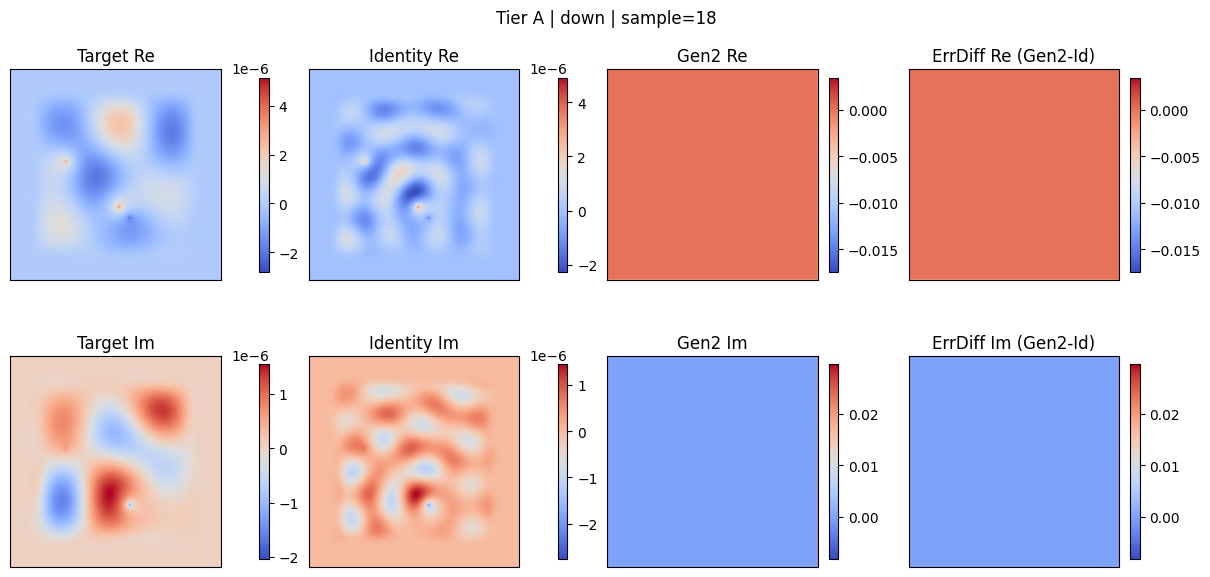

Failing case: Tier A | up | sample=40


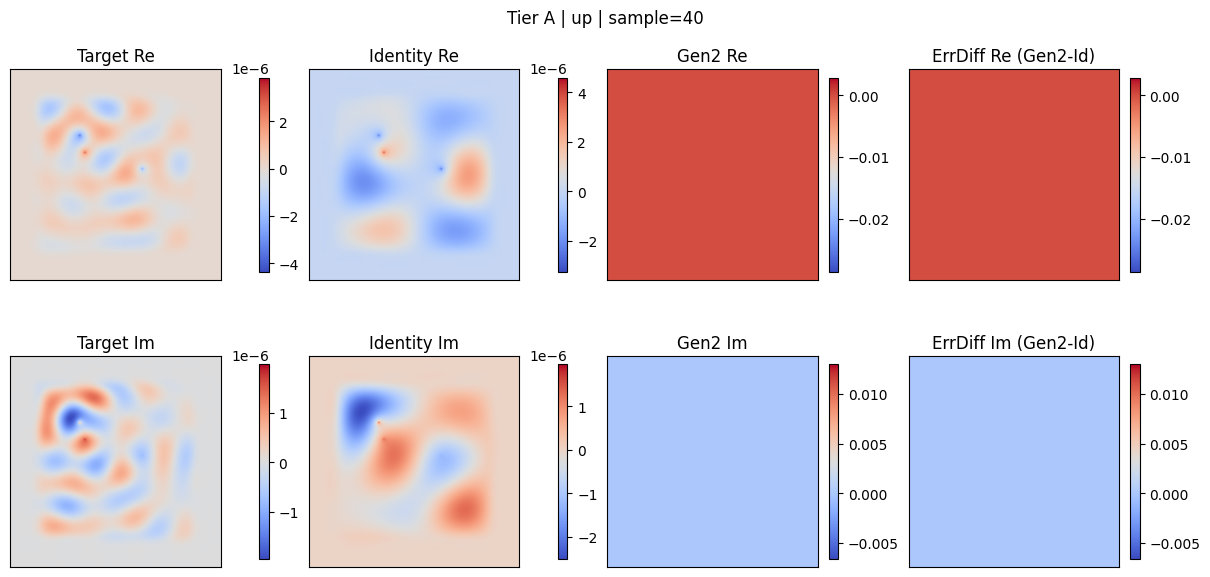

Failing case: Tier B | down | sample=8


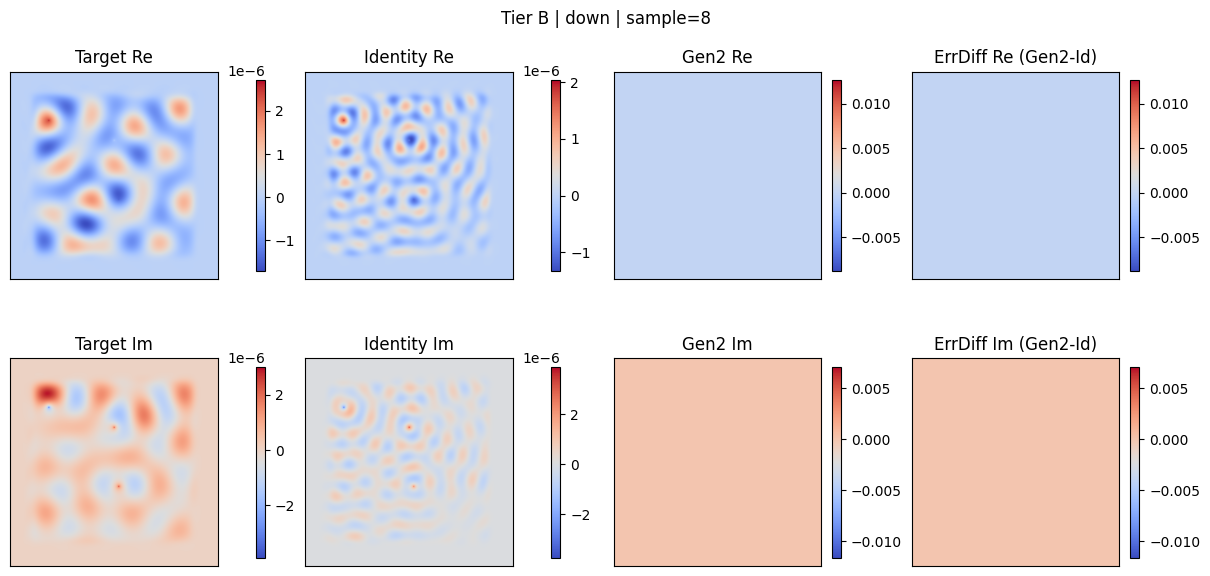

Failing case: Tier B | up | sample=8


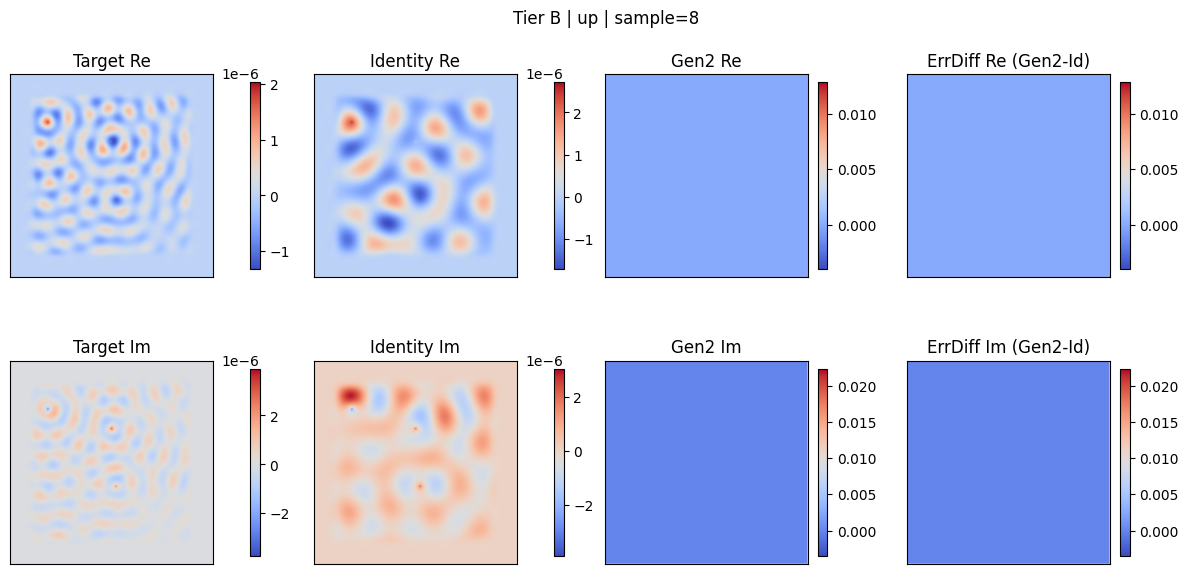

Failing case: Tier C | down | sample=46


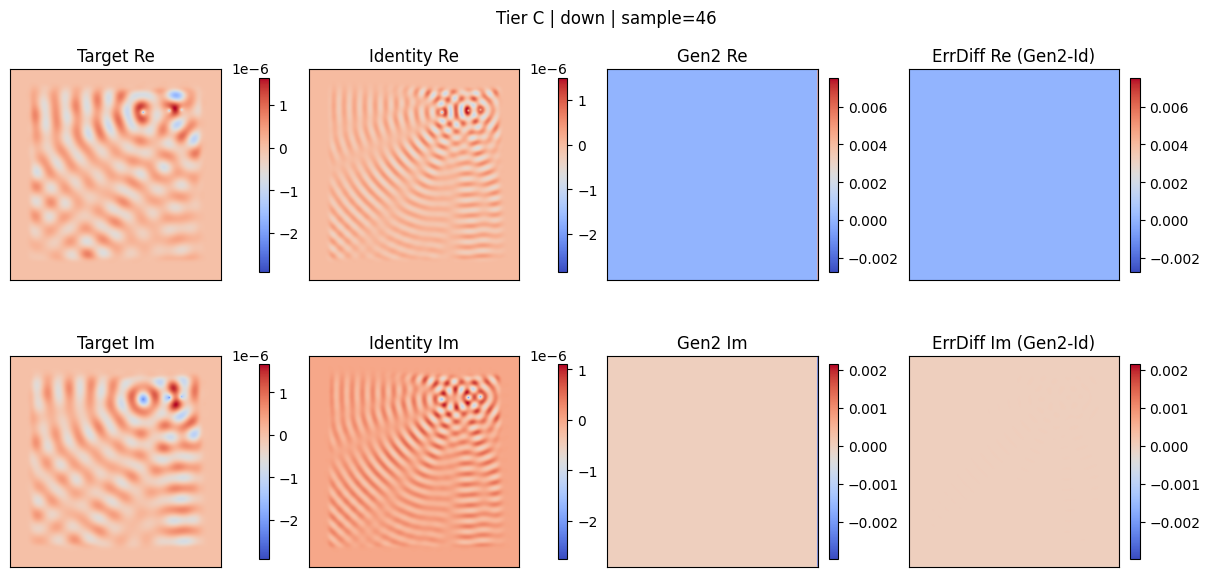

Failing case: Tier C | up | sample=21


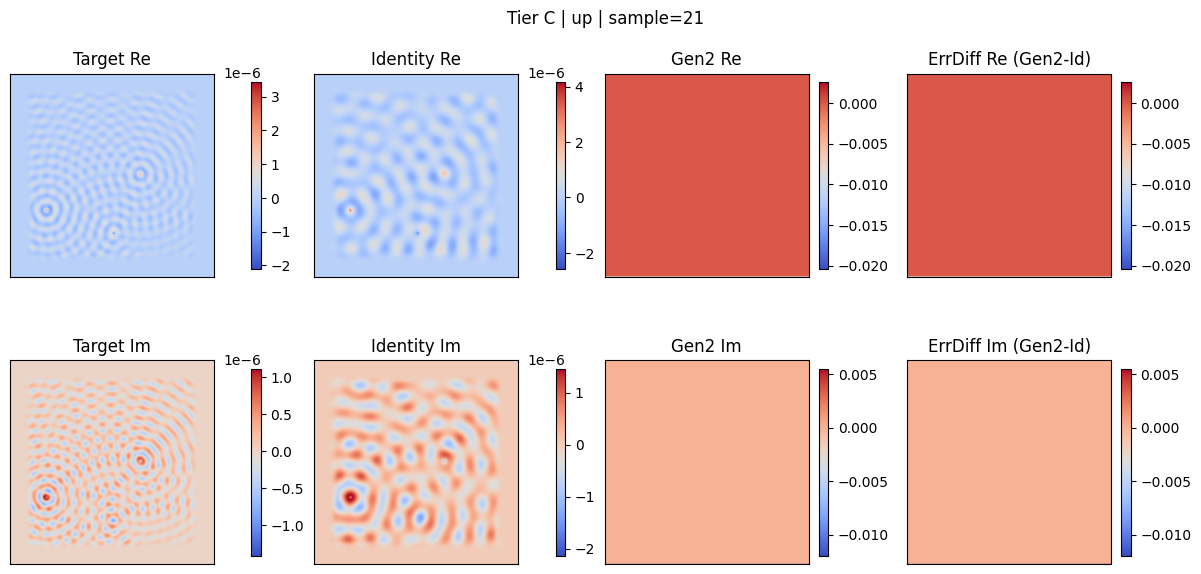

In [23]:
def plot_compare_identity_vs_gen2(X, Y, P_gen2, idx: int, title_prefix: str):
    x = X[idx]
    y = Y[idx]
    p_id = x
    p_g2 = P_gen2[idx]

    e_id = p_id - y
    e_g2 = p_g2 - y

    fig, axs = plt.subplots(2, 4, figsize=(12, 6), constrained_layout=True)
    panels = [
        (y[0], 'Target Re'), (p_id[0], 'Identity Re'), (p_g2[0], 'Gen2 Re'), (e_g2[0] - e_id[0], 'ErrDiff Re (Gen2-Id)'),
        (y[1], 'Target Im'), (p_id[1], 'Identity Im'), (p_g2[1], 'Gen2 Im'), (e_g2[1] - e_id[1], 'ErrDiff Im (Gen2-Id)'),
    ]

    for ax, (arr, ttl) in zip(axs.ravel(), panels):
        im = ax.imshow(arr, origin='lower', cmap='coolwarm')
        ax.set_title(ttl)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle(f'{title_prefix} | sample={idx}', fontsize=12)
    plt.show()

# only plot failing cases and only 1 sample per failing case
if 'worse_df' not in globals():
    worse_df = pd.DataFrame([])

if len(worse_df) == 0:
    print('No failing cases. Gen2 is not worse than identity on the tracked metrics.')
else:
    print(f'Plotting up to {len(worse_df)} targeted diagnostic figure(s).')
    for _, row in worse_df.iterrows():
        tier = row['tier']
        direction = row['direction']
        X, Y, P = pred_cache[(tier, direction)]

        # choose worst sample for this case by combined Gen2 relative error
        sub = sample_df[(sample_df['tier'] == tier) & (sample_df['direction'] == direction)].sort_values('score', ascending=False)
        idx = int(sub.iloc[0]['sample'])

        print(f'Failing case: {tier} | {direction} | sample={idx}')
        plot_compare_identity_vs_gen2(X, Y, P, idx, f'{tier} | {direction}')


## 7) Save Validation Report

All validation outputs are saved for reproducibility and discussion.


In [24]:
out_dir = ROOT / 'experiments' / 'models' / 'transfer_operator_generations' / 'gemitest_validation'
out_dir.mkdir(parents=True, exist_ok=True)

load_df.to_csv(out_dir / 'weight_load_integrity.csv', index=False)
results_df.to_csv(out_dir / 'gen2_vs_identity_test_metrics.csv', index=False)
sample_df.to_csv(out_dir / 'per_sample_errors.csv', index=False)
summary_df.to_csv(out_dir / 'error_percentile_summary.csv', index=False)

print('Saved validation artifacts to:', out_dir)


Saved validation artifacts to: /math/home/fkiewiet/Freq2Transfer/experiments/experiments/models/transfer_operator_generations/gemitest_validation


## 8) Failure Forensics: Why Transfer Appears Inactive or Wrong

This section tests likely root causes from multiple perspectives:

1. **Scale mismatch** between target and model output.
2. **Identity baseline dominance** (if mapping is near identity, weak models can underperform badly).
3. **Bias-dominated predictions** via zero-input response and last-layer bias magnitude.


In [25]:
# A) Scale diagnostics: target vs prediction amplitude
scale_rows = []
for (tier, direction), (X, Y, P) in pred_cache.items():
    y_std_re = float(Y[:, 0].std())
    y_std_im = float(Y[:, 1].std())
    p_std_re = float(P[:, 0].std())
    p_std_im = float(P[:, 1].std())

    scale_rows.append({
        'tier': tier,
        'direction': direction,
        'target_std_re': y_std_re,
        'pred_std_re': p_std_re,
        'pred/target_std_re': p_std_re / max(y_std_re, 1e-30),
        'target_std_im': y_std_im,
        'pred_std_im': p_std_im,
        'pred/target_std_im': p_std_im / max(y_std_im, 1e-30),
    })

scale_df = pd.DataFrame(scale_rows).sort_values(['tier','direction'])
print('If pred/target std ratio >> 1, outputs are over-scaled (bad sign).')
display(scale_df)


If pred/target std ratio >> 1, outputs are over-scaled (bad sign).


,tier,direction,target_std_re,pred_std_re,pred/target_std_re,target_std_im,pred_std_im,pred/target_std_im
1,Tier A,down,9.426125e-07,0.000235,249.524499,9.660203e-07,0.001255,1299.055680
0,Tier A,up,5.730760e-07,0.000456,796.510178,5.934845e-07,0.000087,146.576464
3,Tier B,down,7.521957e-07,0.000047,62.646947,7.145559e-07,0.000045,62.875792
2,Tier B,up,3.761999e-07,0.000539,1433.656428,3.740296e-07,0.000856,2288.460017
5,Tier C,down,3.955222e-07,0.000288,727.586892,4.033456e-07,0.000148,366.200344
4,Tier C,up,2.546863e-07,0.000839,3293.753395,2.534047e-07,0.000255,1004.602780


In [26]:
# B) Identity vs Gen2 dominance check (orders-of-magnitude comparison)
if 'results_df' not in globals():
    raise RuntimeError('results_df not found. Run evaluation section first.')

cmp = results_df.copy()
cmp['mse_re_ratio_gen2_over_id'] = cmp['gen2_mse_re'] / np.maximum(cmp['id_mse_re'], 1e-30)
cmp['mse_im_ratio_gen2_over_id'] = cmp['gen2_mse_im'] / np.maximum(cmp['id_mse_im'], 1e-30)
cmp['rel_re_ratio_gen2_over_id'] = cmp['gen2_rel_l2_re'] / np.maximum(cmp['id_rel_l2_re'], 1e-30)
cmp['rel_im_ratio_gen2_over_id'] = cmp['gen2_rel_l2_im'] / np.maximum(cmp['id_rel_l2_im'], 1e-30)

print('Ratios > 1 mean Gen2 is worse than identity. Large ratios indicate severe failure.')
display(cmp[[
    'tier','direction',
    'mse_re_ratio_gen2_over_id','mse_im_ratio_gen2_over_id',
    'rel_re_ratio_gen2_over_id','rel_im_ratio_gen2_over_id'
]].sort_values(['tier','direction']))


Ratios > 1 mean Gen2 is worse than identity. Large ratios indicate severe failure.


,tier,direction,mse_re_ratio_gen2_over_id,mse_im_ratio_gen2_over_id,rel_re_ratio_gen2_over_id,rel_im_ratio_gen2_over_id
1,Tier A,down,4.445477e+04,1.182883e+06,238.380889,1228.679816
0,Tier A,up,1.674175e+05,5.685964e+03,437.595473,82.205667
3,Tier B,down,3.103987e+03,3.063483e+03,59.257113,58.667005
2,Tier B,up,4.067571e+05,1.112640e+06,664.233442,1093.236357
5,Tier C,down,3.722197e+05,9.554890e+04,630.043396,323.621831
4,Tier C,up,3.162060e+06,2.838226e+05,1835.841645,554.473919


In [27]:
# C) Bias-dominance check: model response to zero input
# If zero input produces large structured output compared to target scale, model is likely bias-dominated.

zero_rows = []
for (tier, direction), info in sorted(models.items()):
    m = info
    x0 = torch.zeros(1, 2, 500, 500, dtype=torch.float32, device=device)
    with torch.no_grad():
        y0 = m(x0).detach().cpu().numpy()[0]

    # inspect last conv bias if available
    last_bias = None
    try:
        last_layer = m.net[-1]
        last_bias = last_layer.bias.detach().cpu().numpy()
    except Exception:
        pass

    zero_rows.append({
        'tier': tier,
        'direction': direction,
        'zero_out_std_re': float(y0[0].std()),
        'zero_out_std_im': float(y0[1].std()),
        'zero_out_max_abs_re': float(np.max(np.abs(y0[0]))),
        'zero_out_max_abs_im': float(np.max(np.abs(y0[1]))),
        'last_bias_re': float(last_bias[0]) if last_bias is not None else np.nan,
        'last_bias_im': float(last_bias[1]) if last_bias is not None else np.nan,
    })

zero_df = pd.DataFrame(zero_rows).sort_values(['tier','direction'])
print('Compare zero-output scales here against target scales in scale_df (target_std_* columns).')
display(zero_df)


Compare zero-output scales here against target scales in scale_df (target_std_* columns).


,tier,direction,zero_out_std_re,zero_out_std_im,zero_out_max_abs_re,zero_out_max_abs_im,last_bias_re,last_bias_im
0,Tier A,down,0.000235,0.001255,0.017395,0.029574,-0.043743,0.045320
1,Tier A,up,0.000456,0.000087,0.028616,0.012957,-0.054873,0.035534
2,Tier B,down,0.000047,0.000045,0.012675,0.011616,-0.016639,-0.030034
3,Tier B,up,0.000539,0.000856,0.012795,0.022256,0.015732,0.042157
4,Tier C,down,0.000288,0.000148,0.007529,0.002963,0.016591,-0.003952
5,Tier C,up,0.000839,0.000255,0.020424,0.011969,-0.031465,-0.015730


## 9) Interpretation Checklist (What Is Most Likely Wrong)

Use the tables above to confirm these failure modes:

1. `pred/target_std_* >> 1`: output scale is far too large relative to true wavefields.
2. `*_ratio_gen2_over_id >> 1`: Gen2 is substantially worse than identity baseline.
3. large zero-input output / large last-layer bias: model behavior is bias-dominated.

If all three are true, the most probable causes are:
- unstable/simple architecture for tiny-amplitude targets,
- training objective not scale-aware,
- missing residual/normalization/zero-init constraints,
- checkpoint provenance mismatch (weights from a different run setup).


In [28]:
# Requires: scale_df, cmp, zero_df already computed in previous cells

thr_scale_ratio = 10.0      # pred/target std >> 1 is bad
thr_mse_ratio = 10.0        # Gen2/Identity MSE ratio >> 1 is bad
thr_zero_target_ratio = 10.0  # zero-input output std >> target std is bad

# merge all needed values
eval_df = (
    scale_df.merge(
        cmp[
            [
                "tier", "direction",
                "mse_re_ratio_gen2_over_id", "mse_im_ratio_gen2_over_id",
                "rel_re_ratio_gen2_over_id", "rel_im_ratio_gen2_over_id",
            ]
        ],
        on=["tier", "direction"],
        how="inner",
    )
    .merge(
        zero_df[
            [
                "tier", "direction",
                "zero_out_std_re", "zero_out_std_im",
                "last_bias_re", "last_bias_im",
            ]
        ],
        on=["tier", "direction"],
        how="inner",
    )
)

# derived ratios for zero-input dominance
eval_df["zero_vs_target_re"] = eval_df["zero_out_std_re"] / np.maximum(eval_df["target_std_re"], 1e-30)
eval_df["zero_vs_target_im"] = eval_df["zero_out_std_im"] / np.maximum(eval_df["target_std_im"], 1e-30)

# checklist flags
eval_df["flag_scale_mismatch"] = (
    (eval_df["pred/target_std_re"] > thr_scale_ratio) |
    (eval_df["pred/target_std_im"] > thr_scale_ratio)
)
eval_df["flag_gen2_worse_than_id"] = (
    (eval_df["mse_re_ratio_gen2_over_id"] > thr_mse_ratio) |
    (eval_df["mse_im_ratio_gen2_over_id"] > thr_mse_ratio)
)
eval_df["flag_bias_dominance"] = (
    (eval_df["zero_vs_target_re"] > thr_zero_target_ratio) |
    (eval_df["zero_vs_target_im"] > thr_zero_target_ratio)
)

eval_df["n_flags"] = (
    eval_df["flag_scale_mismatch"].astype(int) +
    eval_df["flag_gen2_worse_than_id"].astype(int) +
    eval_df["flag_bias_dominance"].astype(int)
)

eval_df["interpretation"] = np.select(
    [
        eval_df["n_flags"] >= 3,
        eval_df["n_flags"] == 2,
        eval_df["n_flags"] == 1,
    ],
    [
        "Severe failure: likely unusable without redesign/retraining",
        "Major issue: investigate before trusting model",
        "Mild issue: monitor and retune",
    ],
    default="No major red flags from this checklist",
)

cols = [
    "tier", "direction",
    "pred/target_std_re", "pred/target_std_im",
    "mse_re_ratio_gen2_over_id", "mse_im_ratio_gen2_over_id",
    "zero_vs_target_re", "zero_vs_target_im",
    "last_bias_re", "last_bias_im",
    "flag_scale_mismatch", "flag_gen2_worse_than_id", "flag_bias_dominance",
    "n_flags", "interpretation",
]
display(eval_df[cols].sort_values(["tier", "direction"]))

print("\nSummary:")
print(eval_df.groupby("interpretation").size())


,tier,direction,pred/target_std_re,pred/target_std_im,mse_re_ratio_gen2_over_id,mse_im_ratio_gen2_over_id,zero_vs_target_re,zero_vs_target_im,last_bias_re,last_bias_im,flag_scale_mismatch,flag_gen2_worse_than_id,flag_bias_dominance,n_flags,interpretation
0,Tier A,down,249.524499,1299.055680,4.445477e+04,1.182883e+06,249.524344,1299.055559,-0.043743,0.045320,True,True,True,3,Severe failure: likely unusable without redesi...
1,Tier A,up,796.510178,146.576464,1.674175e+05,5.685964e+03,796.511346,146.576476,-0.054873,0.035534,True,True,True,3,Severe failure: likely unusable without redesi...
2,Tier B,down,62.646947,62.875792,3.103987e+03,3.063483e+03,62.646918,62.875787,-0.016639,-0.030034,True,True,True,3,Severe failure: likely unusable without redesi...
3,Tier B,up,1433.656428,2288.460017,4.067571e+05,1.112640e+06,1433.656274,2288.459239,0.015732,0.042157,True,True,True,3,Severe failure: likely unusable without redesi...
4,Tier C,down,727.586892,366.200344,3.722197e+05,9.554890e+04,727.586083,366.199875,0.016591,-0.003952,True,True,True,3,Severe failure: likely unusable without redesi...
5,Tier C,up,3293.753395,1004.602780,3.162060e+06,2.838226e+05,3293.755452,1004.602895,-0.031465,-0.015730,True,True,True,3,Severe failure: likely unusable without redesi...



Summary:
interpretation
Severe failure: likely unusable without redesign/retraining    6
dtype: int64


In [29]:
summary_cols = [
    "tier", "direction",
    "pred/target_std_re", "pred/target_std_im",
    "mse_re_ratio_gen2_over_id", "mse_im_ratio_gen2_over_id",
    "zero_vs_target_re", "zero_vs_target_im",
    "n_flags", "interpretation",
]
prof_table = eval_df[summary_cols].copy().sort_values(["n_flags", "tier", "direction"], ascending=[False, True, True])

for c in summary_cols:
    if c not in ["tier", "direction", "interpretation"]:
        prof_table[c] = prof_table[c].astype(float).map(lambda x: f"{x:.2e}")

display(prof_table)


,tier,direction,pred/target_std_re,pred/target_std_im,mse_re_ratio_gen2_over_id,mse_im_ratio_gen2_over_id,zero_vs_target_re,zero_vs_target_im,n_flags,interpretation
0,Tier A,down,2.50e+02,1.30e+03,4.45e+04,1.18e+06,2.50e+02,1.30e+03,3.00e+00,Severe failure: likely unusable without redesi...
1,Tier A,up,7.97e+02,1.47e+02,1.67e+05,5.69e+03,7.97e+02,1.47e+02,3.00e+00,Severe failure: likely unusable without redesi...
2,Tier B,down,6.26e+01,6.29e+01,3.10e+03,3.06e+03,6.26e+01,6.29e+01,3.00e+00,Severe failure: likely unusable without redesi...
3,Tier B,up,1.43e+03,2.29e+03,4.07e+05,1.11e+06,1.43e+03,2.29e+03,3.00e+00,Severe failure: likely unusable without redesi...
4,Tier C,down,7.28e+02,3.66e+02,3.72e+05,9.55e+04,7.28e+02,3.66e+02,3.00e+00,Severe failure: likely unusable without redesi...
5,Tier C,up,3.29e+03,1.00e+03,3.16e+06,2.84e+05,3.29e+03,1.00e+03,3.00e+00,Severe failure: likely unusable without redesi...


## Visualization B: Log-Scale Heatmap of Red-Flag Ratios

Each row is one tier+direction.  
Values > 1 (after log10) indicate orders-of-magnitude issues.


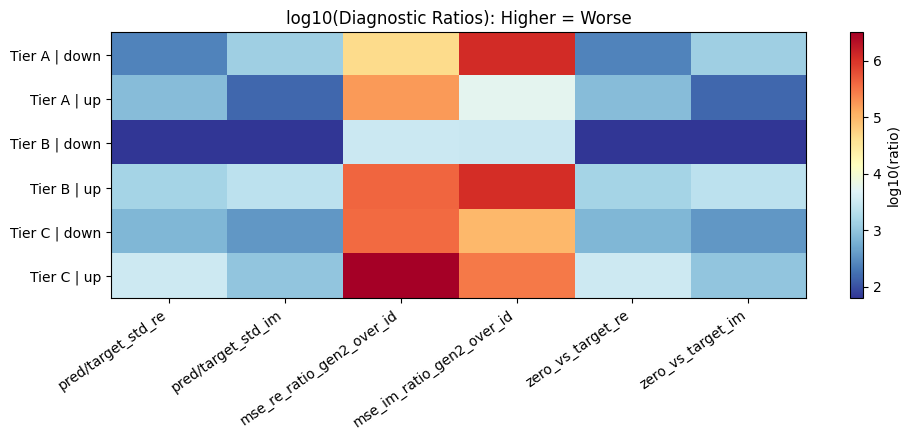

In [30]:
import numpy as np
import matplotlib.pyplot as plt

heat_cols = [
    "pred/target_std_re", "pred/target_std_im",
    "mse_re_ratio_gen2_over_id", "mse_im_ratio_gen2_over_id",
    "zero_vs_target_re", "zero_vs_target_im",
]

H = np.log10(eval_df[heat_cols].to_numpy() + 1e-30)
row_labels = [f"{r.tier} | {r.direction}" for r in eval_df.itertuples()]

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(H, aspect="auto", cmap="RdYlBu_r")
ax.set_xticks(range(len(heat_cols)))
ax.set_xticklabels(heat_cols, rotation=35, ha="right")
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_title("log10(Diagnostic Ratios): Higher = Worse")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(ratio)")
plt.tight_layout()
plt.show()


## Visualization C: Flag Counts by Case

How many of the three checklist tests fail per tier+direction.


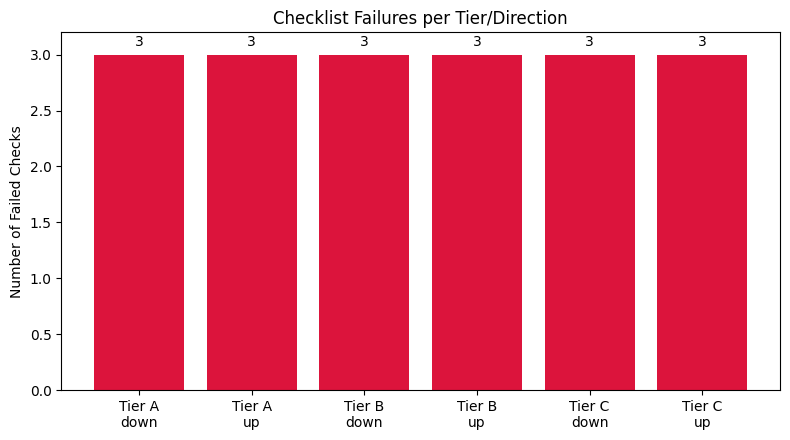

In [32]:
plot_df = eval_df.sort_values(["n_flags", "tier", "direction"], ascending=[False, True, True]).copy()
labels = [f"{r.tier}\n{r.direction}" for r in plot_df.itertuples()]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, plot_df["n_flags"], color=["crimson" if v >= 2 else "goldenrod" if v == 1 else "seagreen" for v in plot_df["n_flags"]])
ax.set_ylim(0, 3.2)
ax.set_ylabel("Number of Failed Checks")
ax.set_title("Checklist Failures per Tier/Direction")
for b, v in zip(bars, plot_df["n_flags"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, str(int(v)), ha="center", va="bottom")
plt.tight_layout()
plt.show()


## Visualization D: Scale Mismatch vs Identity-Relative Error

Each point is one tier+direction.  
Top-right means both scale mismatch and poor performance vs identity.


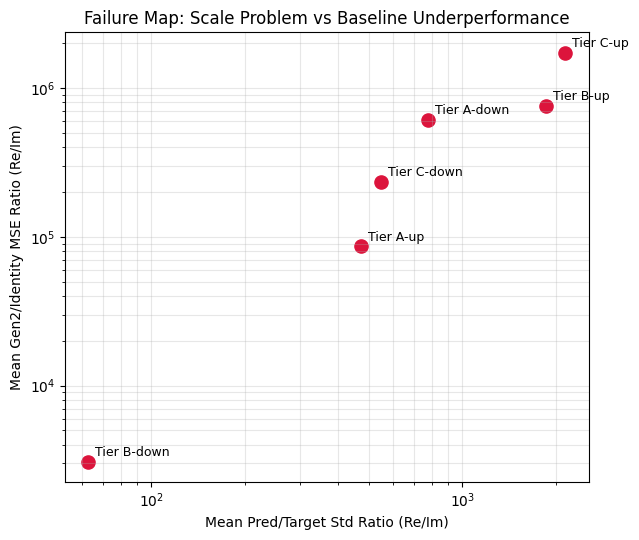

In [33]:
x = 0.5 * (eval_df["pred/target_std_re"] + eval_df["pred/target_std_im"])
y = 0.5 * (eval_df["mse_re_ratio_gen2_over_id"] + eval_df["mse_im_ratio_gen2_over_id"])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for r, xv, yv in zip(eval_df.itertuples(), x, y):
    color = "crimson" if r.n_flags >= 2 else "goldenrod" if r.n_flags == 1 else "seagreen"
    ax.scatter(xv, yv, s=90, color=color)
    ax.annotate(f"{r.tier}-{r.direction}", (xv, yv), xytext=(5, 4), textcoords="offset points", fontsize=9)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Mean Pred/Target Std Ratio (Re/Im)")
ax.set_ylabel("Mean Gen2/Identity MSE Ratio (Re/Im)")
ax.set_title("Failure Map: Scale Problem vs Baseline Underperformance")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization E: Per-Sample Error Distributions (Gen2)

Distribution view to show robustness and outliers for each tier+direction.


/tmp/ipykernel_610006/2819005092.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0].boxplot(data_re, labels=labels, showfliers=True)
/tmp/ipykernel_610006/2819005092.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1].boxplot(data_im, labels=labels, showfliers=True)


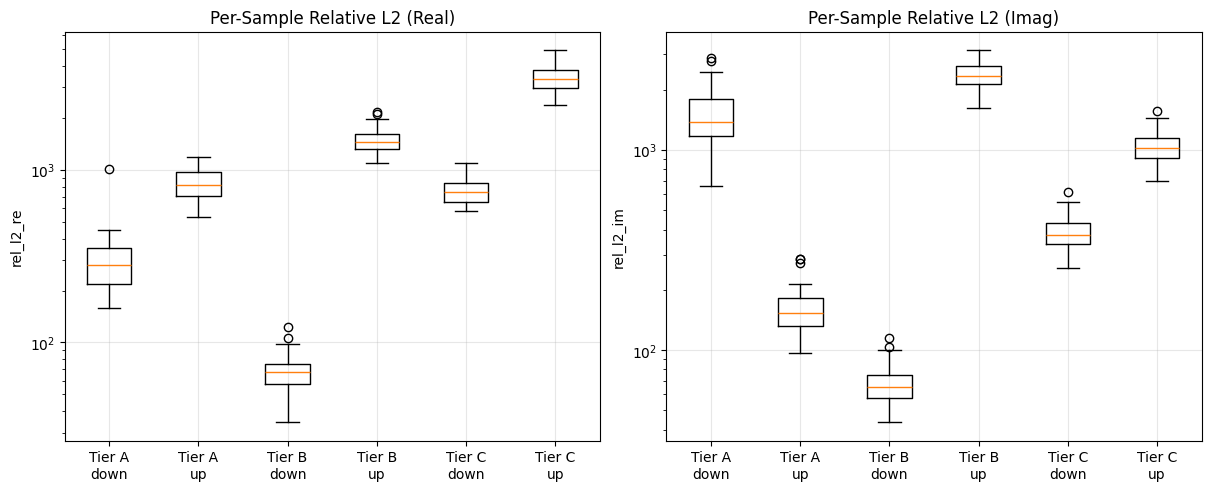

In [34]:
# Requires sample_df from earlier section
groups = sample_df.groupby(["tier", "direction"])
labels = []
data_re = []
data_im = []

for (tier, direction), g in groups:
    labels.append(f"{tier}\n{direction}")
    data_re.append(g["rel_l2_re"].values)
    data_im.append(g["rel_l2_im"].values)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

axs[0].boxplot(data_re, labels=labels, showfliers=True)
axs[0].set_yscale("log")
axs[0].set_title("Per-Sample Relative L2 (Real)")
axs[0].set_ylabel("rel_l2_re")

axs[1].boxplot(data_im, labels=labels, showfliers=True)
axs[1].set_yscale("log")
axs[1].set_title("Per-Sample Relative L2 (Imag)")
axs[1].set_ylabel("rel_l2_im")

for ax in axs:
    ax.grid(alpha=0.3)
plt.show()


## Visualization F: Executive Conclusion Figure

Single figure for presentation: pass/fail color with interpretation text.


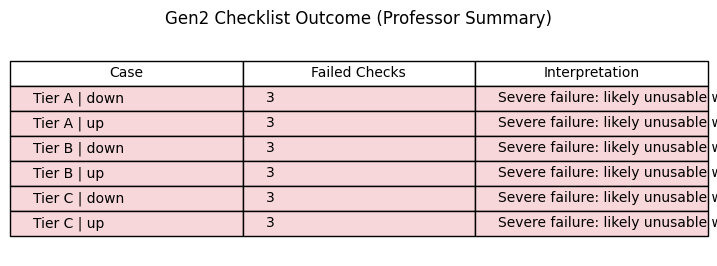

In [35]:
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axis("off")

rows = []
for r in eval_df.sort_values(["n_flags", "tier", "direction"], ascending=[False, True, True]).itertuples():
    rows.append([
        f"{r.tier} | {r.direction}",
        int(r.n_flags),
        r.interpretation
    ])

table = ax.table(
    cellText=rows,
    colLabels=["Case", "Failed Checks", "Interpretation"],
    loc="center",
    cellLoc="left"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

for i, r in enumerate(eval_df.sort_values(["n_flags", "tier", "direction"], ascending=[False, True, True]).itertuples(), start=1):
    color = "#f8d7da" if r.n_flags >= 2 else "#fff3cd" if r.n_flags == 1 else "#d1e7dd"
    for j in range(3):
        table[(i, j)].set_facecolor(color)

ax.set_title("Gen2 Checklist Outcome (Professor Summary)", pad=12)
plt.show()
